# Olist Dataset Audit

**Phase 0B — empirical feasibility audit, not modeling.** This notebook inspects raw tables without modifying them. It distinguishes customers, orders, line items, and products; checks joins before using them; and treats late observations as right-censored. Inactivity is not labeled as churn.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', 100)
RAW = Path('../data/raw/olist')
FILES = sorted(RAW.glob('*.csv'))
assert len(FILES) == 9, f'Expected 9 CSVs, found {len(FILES)}'
tables = {p.stem.replace('olist_', '').replace('_dataset', ''): pd.read_csv(p) for p in FILES}
[(name, df.shape) for name, df in tables.items()]

[('customers', (99441, 5)),
 ('geolocation', (1000163, 5)),
 ('order_items', (112650, 7)),
 ('order_payments', (103886, 5)),
 ('order_reviews', (99224, 7)),
 ('orders', (99441, 8)),
 ('products', (32951, 9)),
 ('sellers', (3095, 4)),
 ('product_category_name_translation', (71, 2))]

## 1. File-level integrity
Each CSV is loaded independently. Missingness is descriptive—not automatically an error—and no rows are dropped or altered.

In [2]:
candidate_keys = {
 'customers': ['customer_id'], 'geolocation': [],
 'order_items': ['order_id', 'order_item_id'],
 'order_payments': ['order_id', 'payment_sequential'],
 'order_reviews': ['review_id', 'order_id'], 'orders': ['order_id'],
 'products': ['product_id'], 'sellers': ['seller_id'],
 'product_category_name_translation': ['product_category_name'],
}
file_summary = []
for name, df in tables.items():
    keys = candidate_keys[name]
    file_summary.append({
        'table': name, 'rows': len(df), 'columns': df.shape[1],
        'memory_mb': df.memory_usage(deep=True).sum()/1024**2,
        'duplicate_rows': int(df.duplicated().sum()),
        'candidate_key': ' + '.join(keys) if keys else 'No single candidate',
        'key_duplicate_rows': int(df.duplicated(keys, keep=False).sum()) if keys else np.nan,
    })
display(pd.DataFrame(file_summary).round({'memory_mb': 2}))
for name, df in tables.items():
    print(f'\n{name}: shape={df.shape}')
    display(pd.DataFrame({'dtype': df.dtypes.astype(str), 'missing_n': df.isna().sum(), 'missing_pct': df.isna().mean().mul(100)}).round(3))

,table,rows,columns,memory_mb,duplicate_rows,candidate_key,key_duplicate_rows
0,customers,99441,5,26.59,0,customer_id,0.0
1,geolocation,1000163,5,129.38,261831,No single candidate,NaN
2,order_items,112650,7,35.99,0,order_id + order_item_id,0.0
3,order_payments,103886,5,16.23,0,order_id + payment_sequential,0.0
4,order_reviews,99224,7,39.12,0,review_id + order_id,0.0
5,orders,99441,8,52.94,0,order_id,0.0
6,products,32951,9,6.30,0,product_id,0.0
7,sellers,3095,4,0.59,0,seller_id,0.0
8,product_category_name_translation,71,2,0.01,0,product_category_name,0.0



customers: shape=(99441, 5)


,dtype,missing_n,missing_pct
customer_id,str,0,0.0
customer_unique_id,str,0,0.0
customer_zip_code_prefix,int64,0,0.0
customer_city,str,0,0.0
customer_state,str,0,0.0



geolocation: shape=(1000163, 5)


,dtype,missing_n,missing_pct
geolocation_zip_code_prefix,int64,0,0.0
geolocation_lat,float64,0,0.0
geolocation_lng,float64,0,0.0
geolocation_city,str,0,0.0
geolocation_state,str,0,0.0


...

,dtype,missing_n,missing_pct
product_id,str,0,0.000
product_category_name,str,610,1.851
product_name_lenght,float64,610,1.851
product_description_lenght,float64,610,1.851
product_photos_qty,float64,610,1.851
product_weight_g,float64,2,0.006
product_length_cm,float64,2,0.006
product_height_cm,float64,2,0.006
product_width_cm,float64,2,0.006



sellers: shape=(3095, 4)


,dtype,missing_n,missing_pct
seller_id,str,0,0.0
seller_zip_code_prefix,int64,0,0.0
seller_city,str,0,0.0
seller_state,str,0,0.0



product_category_name_translation: shape=(71, 2)


,dtype,missing_n,missing_pct
product_category_name,str,0,0.0
product_category_name_english,str,0,0.0


## 2. Observational grain and relational integrity
Key cardinalities validate grain. Unmatched foreign keys are measured before any joins, avoiding silent many-to-many inflation.

In [3]:
grain = pd.DataFrame([
 ['customers', 'one order-specific customer identity', 'customer_id', 'customer_unique_id', len(tables['customers'])],
 ['geolocation', 'one zip-prefix/geocode observation', 'none (repeated prefixes)', 'none', len(tables['geolocation'])],
 ['order_items', 'one item line/sequence within an order', 'order_id + order_item_id', 'order_id, product_id, seller_id', len(tables['order_items'])],
 ['order_payments', 'one payment sequence for an order', 'order_id + payment_sequential', 'order_id', len(tables['order_payments'])],
 ['order_reviews', 'one review record associated with an order', 'review_id + order_id', 'order_id', len(tables['order_reviews'])],
 ['orders', 'one order', 'order_id', 'customer_id', len(tables['orders'])],
 ['products', 'one product', 'product_id', 'product_category_name', len(tables['products'])],
 ['sellers', 'one seller', 'seller_id', 'seller_zip_code_prefix', len(tables['sellers'])],
 ['product_category_name_translation', 'one Portuguese category translation', 'product_category_name', 'none', len(tables['product_category_name_translation'])],
], columns=['table','row_grain','candidate_key','important_foreign_keys','rows'])
display(grain)
customers, orders = tables['customers'], tables['orders']
items, payments = tables['order_items'], tables['order_payments']
reviews, products, sellers = tables['order_reviews'], tables['products'], tables['sellers']
integrity = pd.Series({
 'duplicate customer_id rows': customers.duplicated('customer_id').sum(),
 'customer_unique_id count': customers.customer_unique_id.nunique(),
 'duplicate order_id rows in orders': orders.duplicated('order_id').sum(),
 'orders with multiple item rows': items.groupby('order_id').size().gt(1).sum(),
 'orders with multiple payment rows': payments.groupby('order_id').size().gt(1).sum(),
 'orders with multiple review rows': reviews.groupby('order_id').size().gt(1).sum(),
 'duplicate review_id values': reviews.review_id.duplicated().sum(),
 'duplicate product_id rows': products.duplicated('product_id').sum(),
 'duplicate seller_id rows': sellers.duplicated('seller_id').sum(),
 'orders.customer_id unmatched': (~orders.customer_id.isin(customers.customer_id)).sum(),
 'items.order_id unmatched': (~items.order_id.isin(orders.order_id)).sum(),
 'payments.order_id unmatched': (~payments.order_id.isin(orders.order_id)).sum(),
 'reviews.order_id unmatched': (~reviews.order_id.isin(orders.order_id)).sum(),
 'items.product_id unmatched': (~items.product_id.isin(products.product_id)).sum(),
 'items.seller_id unmatched': (~items.seller_id.isin(sellers.seller_id)).sum(),
})
display(integrity.to_frame('count'))

,table,row_grain,candidate_key,important_foreign_keys,rows
0,customers,one order-specific customer identity,customer_id,customer_unique_id,99441
1,geolocation,one zip-prefix/geocode observation,none (repeated prefixes),none,1000163
2,order_items,one item line/sequence within an order,order_id + order_item_id,"order_id, product_id, seller_id",112650
3,order_payments,one payment sequence for an order,order_id + payment_sequential,order_id,103886
4,order_reviews,one review record associated with an order,review_id + order_id,order_id,99224
5,orders,one order,order_id,customer_id,99441
6,products,one product,product_id,product_category_name,32951
7,sellers,one seller,seller_id,seller_zip_code_prefix,3095
8,product_category_name_translation,one Portuguese category translation,product_category_name,none,71


,count
duplicate customer_id rows,0
customer_unique_id count,96096
duplicate order_id rows in orders,0
orders with multiple item rows,9803
orders with multiple payment rows,2961
orders with multiple review rows,547
duplicate review_id values,814
duplicate product_id rows,0
duplicate seller_id rows,0
orders.customer_id unmatched,0


## 3. Temporal audit
Dates are parsed with coercion so malformed values become visible. Monthly volume and boundary coverage matter for future temporal validation.

In [4]:
timestamp_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
orders_dt = orders.copy()
for c in timestamp_cols: orders_dt[c] = pd.to_datetime(orders_dt[c], errors='coerce')
temporal = pd.DataFrame([{
 'column': c, 'earliest': orders_dt[c].min(), 'latest': orders_dt[c].max(),
 'missing_n': orders_dt[c].isna().sum(), 'missing_pct': orders_dt[c].isna().mean()*100
} for c in timestamp_cols])
display(temporal)
purchase = orders_dt.order_purchase_timestamp
print('Coverage days:', (purchase.max() - purchase.min()).days)
monthly = purchase.dt.to_period('M').value_counts().sort_index().rename('orders').to_frame()
display(monthly)
display(orders.order_status.value_counts(dropna=False).to_frame('orders'))
print('Boundary months are partial:', purchase.min(), 'to', purchase.max())
full_days = pd.date_range(purchase.dt.floor('D').min(), purchase.dt.floor('D').max(), freq='D')
missing_days = full_days.difference(pd.DatetimeIndex(purchase.dt.floor('D').dropna().unique()))
print('Calendar days with zero purchases:', len(missing_days), list(missing_days[:20]))

,column,earliest,latest,missing_n,missing_pct
0,order_purchase_timestamp,2016-09-04 21:15:19,2018-10-17 17:30:18,0,0.000000
1,order_approved_at,2016-09-15 12:16:38,2018-09-03 17:40:06,160,0.160899
2,order_delivered_carrier_date,2016-10-08 10:34:01,2018-09-11 19:48:28,1783,1.793023
3,order_delivered_customer_date,2016-10-11 13:46:32,2018-10-17 13:22:46,2965,2.981668
4,order_estimated_delivery_date,2016-09-30 00:00:00,2018-11-12 00:00:00,0,0.000000


Coverage days: 772


,orders
order_purchase_timestamp,
2016-09,4
2016-10,324
2016-12,1
2017-01,800
2017-02,1780
2017-03,2682
2017-04,2404
2017-05,3700
2017-06,3245


,orders
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


Boundary months are partial: 2016-09-04 21:15:19 to 2018-10-17 17:30:18
Calendar days with zero purchases: 140 [Timestamp('2016-09-06 00:00:00'), Timestamp('2016-09-07 00:00:00'), Timestamp('2016-09-08 00:00:00'), Timestamp('2016-09-09 00:00:00'), Timestamp('2016-09-10 00:00:00'), Timestamp('2016-09-11 00:00:00'), Timestamp('2016-09-12 00:00:00'), Timestamp('2016-09-14 00:00:00'), Timestamp('2016-09-16 00:00:00'), Timestamp('2016-09-17 00:00:00'), Timestamp('2016-09-18 00:00:00'), Timestamp('2016-09-19 00:00:00'), Timestamp('2016-09-20 00:00:00'), Timestamp('2016-09-21 00:00:00'), Timestamp('2016-09-22 00:00:00'), Timestamp('2016-09-23 00:00:00'), Timestamp('2016-09-24 00:00:00'), Timestamp('2016-09-25 00:00:00'), Timestamp('2016-09-26 00:00:00'), Timestamp('2016-09-27 00:00:00')]


## 4. Customer identity and repeat purchases
`customer_id` is order-specific; `customer_unique_id` links identities across orders. Counts below use distinct `order_id`, never item rows. A valid purchase is conservatively treated as an order not marked canceled or unavailable; this is descriptive, not a churn label.

In [5]:
customer_orders = orders_dt.merge(customers[['customer_id','customer_unique_id']], on='customer_id', how='left', validate='many_to_one')
valid = customer_orders.loc[~customer_orders.order_status.isin(['canceled','unavailable'])].copy()
order_counts = valid.groupby('customer_unique_id').order_id.nunique()
repeat_stats = pd.Series({
 'unique customer_id': customers.customer_id.nunique(),
 'unique customer_unique_id': customers.customer_unique_id.nunique(),
 'valid-purchase customers': order_counts.size,
 'exactly 1 order pct': order_counts.eq(1).mean()*100,
 'at least 2 orders pct': order_counts.ge(2).mean()*100,
 'at least 3 orders pct': order_counts.ge(3).mean()*100,
 'maximum orders': order_counts.max(),
 'median orders': order_counts.median(),
})
display(repeat_stats.to_frame('value'))
display(order_counts.value_counts().sort_index().rename('customers').to_frame().head(20))

,value
unique customer_id,99441.000000
unique customer_unique_id,96096.000000
valid-purchase customers,94990.000000
exactly 1 order pct,96.959680
at least 2 orders pct,3.040320
at least 3 orders pct,0.248447
maximum orders,16.000000
median orders,1.000000


,customers
order_id,
1,92102
2,2652
3,188
4,29
5,9
6,5
7,3
9,1
16,1


## 5. Repeat-purchase timing
Intervals use consecutive distinct valid orders for customers with at least two orders. They describe observed cadence only and do not define churn.

,days
count,3217.000000
mean,78.890237
25%,0.004965
50%,29.017211
75%,120.748137
90%,241.833988


,value
intervals under 1 day,965.000000
intervals under 1 day pct,29.996892
zero-day intervals,283.000000


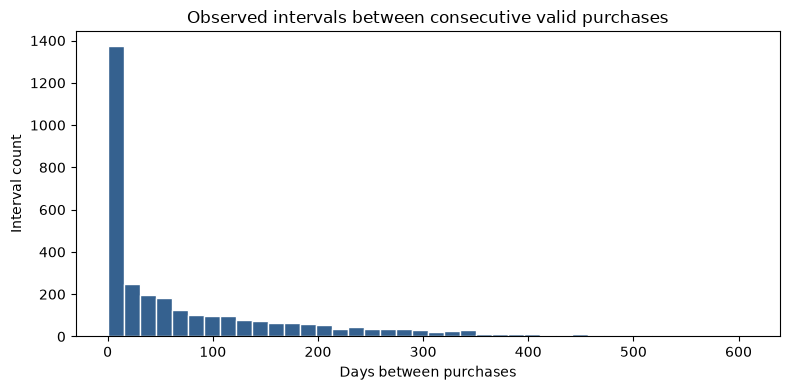

Interpretation: the distribution describes observed repeat cadence only; the fixed dataset end censors later opportunities to return.


In [6]:
valid_distinct = valid[['customer_unique_id','order_id','order_purchase_timestamp']].drop_duplicates().sort_values(['customer_unique_id','order_purchase_timestamp'])
intervals = valid_distinct.groupby('customer_unique_id').order_purchase_timestamp.diff().dt.total_seconds().div(86400).dropna()
interval_summary = intervals.describe(percentiles=[.25,.5,.75,.9])[['count','mean','25%','50%','75%','90%']]
display(interval_summary.to_frame('days'))
display(pd.Series({'intervals under 1 day': intervals.lt(1).sum(), 'intervals under 1 day pct': intervals.lt(1).mean()*100, 'zero-day intervals': intervals.eq(0).sum()}).to_frame('value'))
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(intervals, bins=40, color='#35618f', edgecolor='white')
ax.set(title='Observed intervals between consecutive valid purchases', xlabel='Days between purchases', ylabel='Interval count')
plt.tight_layout(); plt.show()
print('Interpretation: the distribution describes observed repeat cadence only; the fixed dataset end censors later opportunities to return.')

## 6. Right-censoring by first-purchase cohort
Later cohorts have less follow-up before the last observed purchase date, so raw observed repeat rates are not directly comparable.

,first_month,customers,repeat_customer_pct,available_followup_days
0,2016-09,2,0.000000,728
1,2016-10,290,4.137931,699
2,2016-12,1,100.000000,618
3,2017-01,752,7.313830,605
4,2017-02,1690,4.142012,579
5,2017-03,2571,5.017503,551
6,2017-04,2325,4.559140,520
7,2017-05,3541,5.337475,490
8,2017-06,3102,5.383623,459
9,2017-07,3822,4.683412,429


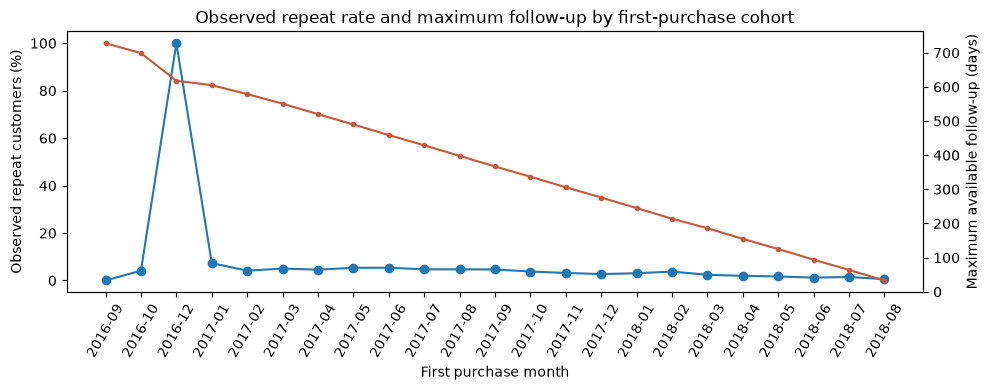

Interpretation: falling late-cohort repeat rates are confounded by shorter follow-up and cannot be read as higher return risk.


In [7]:
cust_dates = valid_distinct.groupby('customer_unique_id').agg(first_purchase=('order_purchase_timestamp','min'), orders=('order_id','nunique'))
dataset_end = valid.order_purchase_timestamp.max()
cust_dates['first_month'] = cust_dates.first_purchase.dt.to_period('M')
cust_dates['followup_days'] = (dataset_end - cust_dates.first_purchase).dt.days
cohorts = cust_dates.groupby('first_month').agg(customers=('orders','size'), repeat_customer_pct=('orders', lambda s: s.ge(2).mean()*100), available_followup_days=('followup_days','max')).reset_index()
display(cohorts)
fig, ax1 = plt.subplots(figsize=(10,4))
ax1.plot(cohorts.first_month.astype(str), cohorts.repeat_customer_pct, marker='o', label='Observed repeat %')
ax1.set(title='Observed repeat rate and maximum follow-up by first-purchase cohort', xlabel='First purchase month', ylabel='Observed repeat customers (%)')
ax1.tick_params(axis='x', rotation=60)
ax2 = ax1.twinx(); ax2.plot(cohorts.first_month.astype(str), cohorts.available_followup_days, color='#c45a3c', marker='.', label='Follow-up days'); ax2.set_ylabel('Maximum available follow-up (days)')
plt.tight_layout(); plt.show()
print('Interpretation: falling late-cohort repeat rates are confounded by shorter follow-up and cannot be read as higher return risk.')

## 7. Segmentation feasibility (no feature matrix, no clustering)
Availability below concerns construction potential. Predictive use would require features frozen at a historical cutoff; full-history recency, reviews, payments, or delivery outcomes can leak future information.

In [8]:
feature_audit = pd.DataFrame([
 ['Recency','Derivable','Purchase timestamps; must be relative to a defined snapshot.'],
 ['Distinct order frequency','Derivable','Distinct order_id before snapshot; exclude canceled/unavailable consistently.'],
 ['Monetary value','Derivable','Aggregate order-item price/freight or payments, but never sum both as the same spend.'],
 ['Average order value','Derivable','Requires order-level aggregation before customer aggregation.'],
 ['Purchased item count','Derivable','Order-item row grain; audit quantity interpretation and cancellations.'],
 ['Unique products','Derivable','Distinct product_id in pre-snapshot item rows.'],
 ['Unique categories','Derivable','Join item→product many-to-one; missing product categories exist.'],
 ['Average review score','Problematic','Join reviews at order level; post-purchase score may be unavailable at prediction time.'],
 ['Freight spending','Derivable','Order-item freight; aggregate once and keep interpretation explicit.'],
 ['Payment behavior','Derivable','Aggregate multiple payment rows per order first; installments/payment type can be cutoff-safe.'],
 ['Operational inventory','Unavailable','No on-hand stock ledger.'],
], columns=['candidate_feature','status','reason_or_temporal_concern'])
display(feature_audit)

,candidate_feature,status,reason_or_temporal_concern
0,Recency,Derivable,Purchase timestamps; must be relative to a def...
1,Distinct order frequency,Derivable,Distinct order_id before snapshot; exclude can...
2,Monetary value,Derivable,Aggregate order-item price/freight or payments...
3,Average order value,Derivable,Requires order-level aggregation before custom...
4,Purchased item count,Derivable,Order-item row grain; audit quantity interpret...
5,Unique products,Derivable,Distinct product_id in pre-snapshot item rows.
6,Unique categories,Derivable,Join item→product many-to-one; missing product...
7,Average review score,Problematic,Join reviews at order level; post-purchase sco...
8,Freight spending,Derivable,Order-item freight; aggregate once and keep in...
9,Payment behavior,Derivable,Aggregate multiple payment rows per order firs...


## 8. Recommendation feasibility
Interactions are distinct customer–product purchases from valid orders. Olist has no view/cart feedback, so non-purchase is not negative preference.

In [9]:
valid_items = valid[['order_id','customer_unique_id']].merge(items[['order_id','product_id']], on='order_id', how='inner', validate='one_to_many')
pairs = valid_items[['customer_unique_id','product_id']].drop_duplicates()
per_user = pairs.groupby('customer_unique_id').product_id.nunique()
per_product = pairs.groupby('product_id').customer_unique_id.nunique()
possible = int(pairs.customer_unique_id.nunique()) * int(pairs.product_id.nunique())
rec_stats = pd.Series({
 'unique customers': pairs.customer_unique_id.nunique(), 'unique products': pairs.product_id.nunique(),
 'distinct customer-product interactions': len(pairs),
 'mean interactions per customer': per_user.mean(), 'median interactions per customer': per_user.median(),
 'mean interactions per product': per_product.mean(), 'median interactions per product': per_product.median(),
 'matrix sparsity pct': (1 - len(pairs)/possible)*100,
 'customers with 1 distinct product pct': per_user.eq(1).mean()*100,
 'customers with multiple products pct': per_user.gt(1).mean()*100,
 'repeated customer-product row occurrences': len(valid_items)-len(pairs),
 'customer-product pairs purchased in multiple orders': valid_items.groupby(['customer_unique_id','product_id']).order_id.nunique().gt(1).sum(),
})
display(rec_stats.to_frame('value'))

,value
unique customers,94983.000000
unique products,32729.000000
distinct customer-product interactions,101521.000000
mean interactions per customer,1.068833
median interactions per customer,1.000000
mean interactions per product,3.101867
median interactions per product,1.000000
matrix sparsity pct,99.996734
customers with 1 distinct product pct,94.282135
customers with multiple products pct,5.717865


## 9. Lightweight sales-series feasibility
No forecasts are fit. We only measure density of observed item rows at total-day, category-day, and product-day levels within the valid-order date range.

In [10]:
sales = valid[['order_id','order_purchase_timestamp']].merge(items[['order_id','product_id']], on='order_id', how='inner', validate='one_to_many').merge(products[['product_id','product_category_name']], on='product_id', how='left', validate='many_to_one')
sales['day'] = sales.order_purchase_timestamp.dt.floor('D')
n_days = sales.day.nunique(); calendar_days = (sales.day.max()-sales.day.min()).days+1
cat_counts = sales.groupby(['product_category_name','day']).size()
prod_counts = sales.groupby(['product_id','day']).size()
sales_feas = pd.Series({
 'calendar days in range': calendar_days, 'days with total sales': n_days, 'total-day zero pct': (1-n_days/calendar_days)*100,
 'categories': sales.product_category_name.nunique(), 'observed category-days': len(cat_counts),
 'category-day density pct': len(cat_counts)/(sales.product_category_name.nunique()*calendar_days)*100,
 'products': sales.product_id.nunique(), 'observed product-days': len(prod_counts),
 'product-day density pct': len(prod_counts)/(sales.product_id.nunique()*calendar_days)*100,
 'median active days per category': cat_counts.groupby(level=0).size().median(),
 'median active days per product': prod_counts.groupby(level=0).size().median(),
})
display(sales_feas.to_frame('value'))

,value
calendar days in range,730.000000
days with total sales,614.000000
total-day zero pct,15.890411
categories,73.000000
observed category-days,18461.000000
category-day density pct,34.642522
products,32729.000000
observed product-days,94142.000000
product-day density pct,0.394029
median active days per category,180.000000


## 10. Cancellations and returns
Order status explicitly represents cancellations; it does not by itself prove refunds or product returns. Timestamp patterns are documented without imputing or deleting observations.

In [11]:
status_timestamps = orders_dt.groupby('order_status')[timestamp_cols].agg(lambda s: s.notna().sum())
status_timestamps.insert(0, 'orders', orders_dt.groupby('order_status').size())
display(status_timestamps)
print('Canceled orders:', orders.order_status.eq('canceled').sum())
print('Explicit return/refund status values:', [s for s in orders.order_status.dropna().unique() if 'return' in s.lower() or 'refund' in s.lower()])
print('Conclusion: cancellations are explicit. A distinct refund or product-return process is not evidenced by order_status and must not be assumed.')

,orders,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
order_status,,,,,,
approved,2,2,2,0,0,2
canceled,625,625,484,75,6,625
created,5,5,0,0,0,5
delivered,96478,96478,96464,96476,96470,96478
invoiced,314,314,314,0,0,314
processing,301,301,301,0,0,301
shipped,1107,1107,1107,1107,0,1107
unavailable,609,609,609,0,0,609


Canceled orders: 625
Explicit return/refund status values: []
Conclusion: cancellations are explicit. A distinct refund or product-return process is not evidenced by order_status and must not be assumed.


## Methodological conclusion

This audit is descriptive. It creates no model, cluster, recommender, forecast, or return-risk target. Any later predictive dataset must choose a historical cutoff, build features only from information available by that cutoff, preserve entity grain, and reserve adequate future follow-up. Suspicious values, missingness, boundaries, and outliers require documented investigation rather than automatic removal.